In [1]:
import json
from google.colab import drive

# Mount Google Drive to access files
drive.mount('/content/drive')

Mounted at /content/drive


Prompt for Data Annotation

In [ ]:
# System prompt, defining the emotion analysis task
system_prompt = """You will receive a tweet text. Please analyze the six basic emotions (anger, disgust, fear, joy, sadness, surprise) and their intensities, and identify the framing strategy used in the message.

Classify emotions according to Ekman's model, using a 0.0-1.0 continuous scale to represent emotion intensity:
0.0 = non-existent
0.1-0.3 = mild
0.4-0.6 = moderate
0.7-0.9 = strong
1.0 = extreme

Framing strategies are defined as:
- **Diagnostic**: Identifies a problem or issue related to the movement.
  - *Example*: "Crime rates are increasing due to government negligence."
- **Prognostic**: Suggests solutions or approaches to address the problem.
  - *Example*: "Implementing community policing can reduce crime rates."
- **Motivational**: Calls for action or encourages participation.
  - *Example*: "Join the rally to support police reform this Saturday."
- **Irrelevant**: The tweet does not contribute to the discussion about the movement.
  - *Example*: "I just had the best coffee this morning!"

Return only a JSON containing emotion classifications, intensity values, and the identified framing strategy, without any explanation. Format as follows:
{
  "emotions": {
    "anger": value,
    "disgust": value,
    "fear": value,
    "joy": value,
    "sadness": value,
    "surprise": value
  },
  "dominant_emotion": "name of dominant emotion",
  "framing_strategy": "diagnostic" | "prognostic" | "motivational" | "irrelevant"
}

If multiple emotions have the same highest intensity, select the first one in alphabetical order as the dominant emotion."""

Descriptive data

Loading data from: /content/drive/My Drive/combined_sent_data.json
Data successfully loaded. Total entries: 130178
Unique posts (based on conversationId): 130178

Processed 130178 entries with complete sentiment data.

Dominant Emotion Distribution:
anger: 66984 (51.46%)
joy: 41614 (31.97%)
sadness: 12900 (9.91%)
fear: 3978 (3.06%)
surprise: 2937 (2.26%)
disgust: 1765 (1.36%)

Framing Strategy Distribution:
diagnostic: 63989 (49.16%)
motivational: 54047 (41.52%)
irrelevant: 9489 (7.29%)
prognostic: 2653 (2.04%)

Average Emotion Intensity:
anger: 0.4655
disgust: 0.3393
fear: 0.2338
joy: 0.2322
sadness: 0.3196
surprise: 0.1839

Chi-square Test Result: chi2=59660.15, p-value=0.0000
Cramér's V (Overall Association Strength): 0.3909

Visualization saved at: /content/drive/My Drive/sentiment_association_results.png
Additional visualization saved at: /content/drive/My Drive/emotion_intensity_by_strategy.png


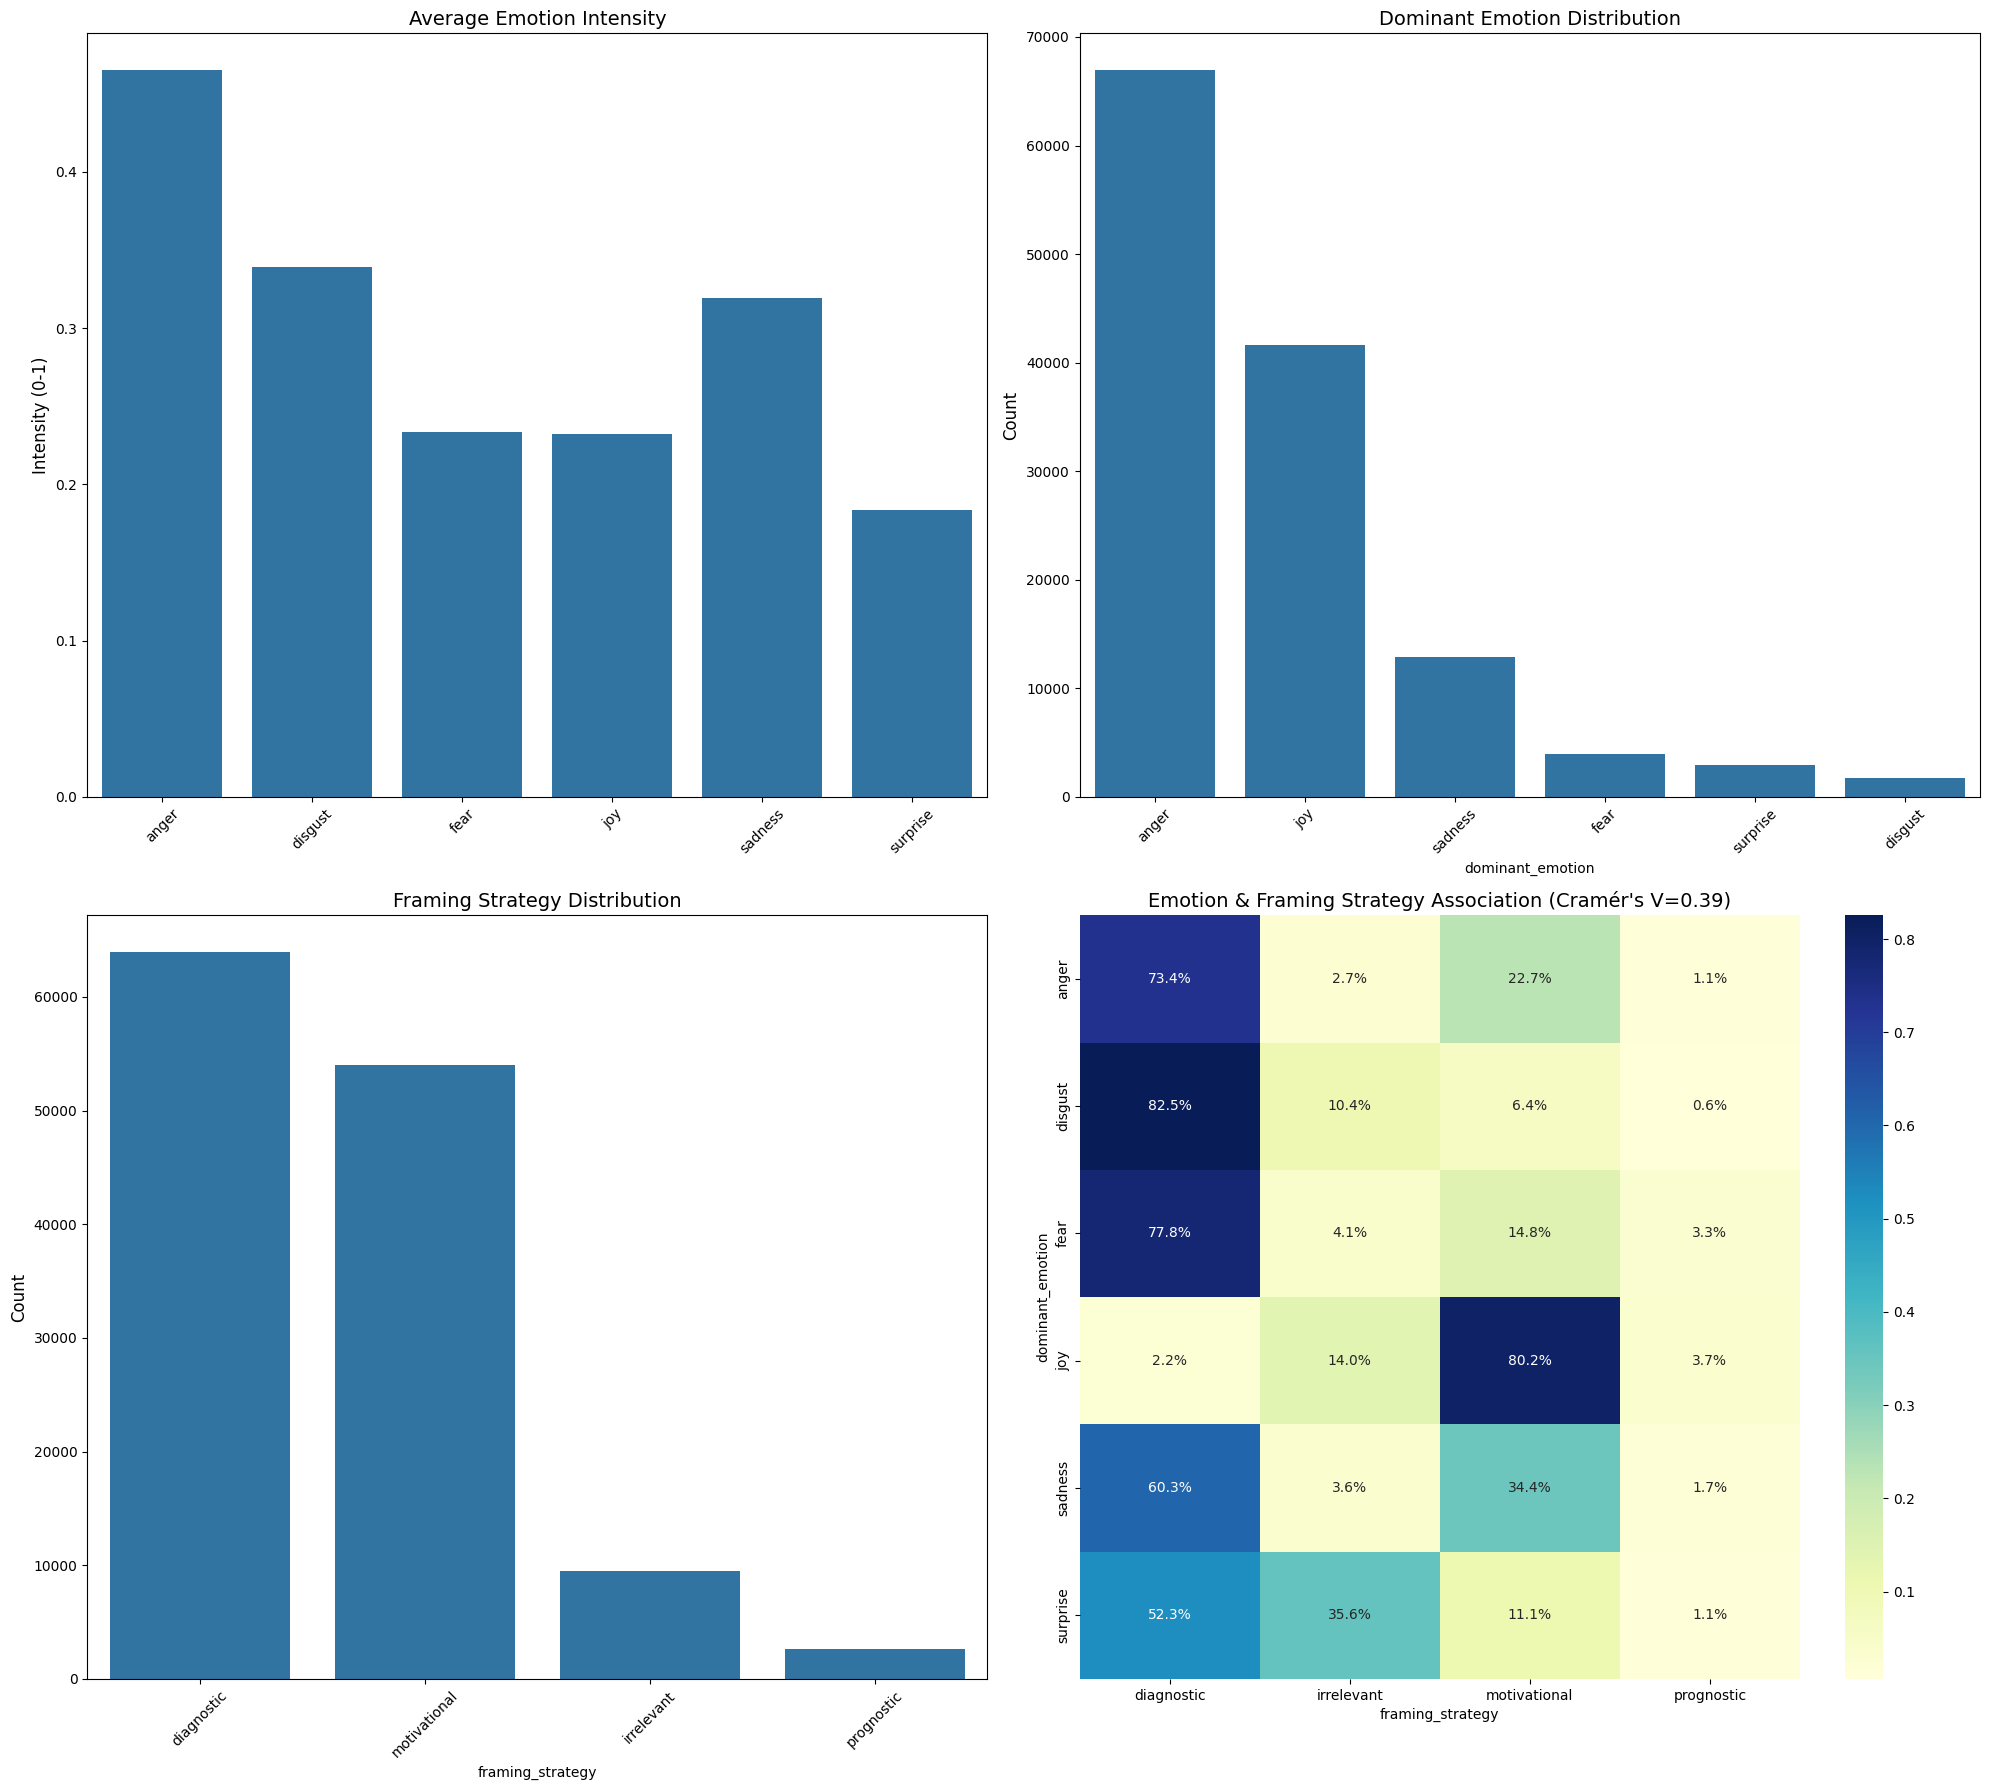

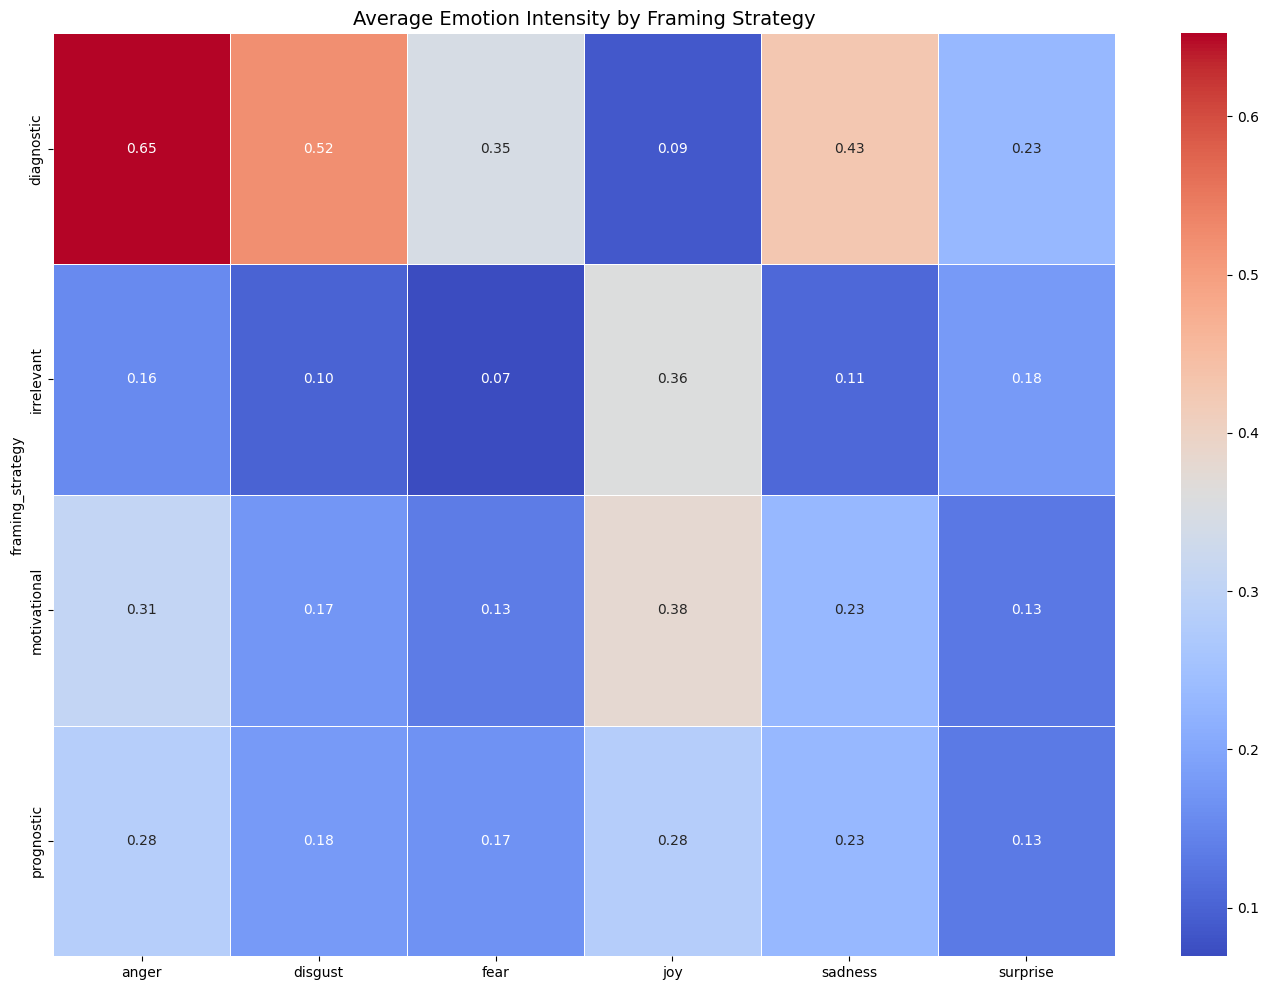

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency

# Specify the JSON file path - Update this with your actual file location
file_path = '/content/drive/My Drive/combined_sent_data.json'

# Load JSON data
print("Loading data from:", file_path)
try:
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)
    print(f"Data successfully loaded. Total entries: {len(data)}")
except FileNotFoundError:
    print(f"File not found: {file_path}")
    print("Please check if the file path is correct and the file exists.")
    exit()
except json.JSONDecodeError:
    print("Error parsing the JSON file. The file might be corrupted.")
    exit()

# Count the number of unique posts based on conversationId
unique_conversation_ids = set()
for entry in data:
    if 'conversationId' in entry:
        unique_conversation_ids.add(entry['conversationId'])

print(f"Unique posts (based on conversationId): {len(unique_conversation_ids)}")

# Extract sentiment data for each entry
entries_with_emotions = []
for entry in data:
    if 'emotion_analysis' in entry and entry['emotion_analysis'] is not None:
        analysis = entry['emotion_analysis']
        if 'emotions' in analysis and 'dominant_emotion' in analysis and 'framing_strategy' in analysis:
            entry_data = {
                'conversationId': entry.get('conversationId', 'unknown'),
                'dominant_emotion': analysis['dominant_emotion'],
                'framing_strategy': analysis['framing_strategy']
            }
            # Add intensity values for each emotion
            for emotion, value in analysis['emotions'].items():
                entry_data[emotion] = value

            entries_with_emotions.append(entry_data)

# Create DataFrame from extracted data
if entries_with_emotions:
    df_emotions = pd.DataFrame(entries_with_emotions)
    print(f"\nProcessed {len(df_emotions)} entries with complete sentiment data.")

    # Basic statistics
    print("\nDominant Emotion Distribution:")
    dominant_counts = df_emotions['dominant_emotion'].value_counts()
    for emotion, count in dominant_counts.items():
        print(f"{emotion}: {count} ({count/len(df_emotions)*100:.2f}%)")

    print("\nFraming Strategy Distribution:")
    strategy_counts = df_emotions['framing_strategy'].value_counts()
    for strategy, count in strategy_counts.items():
        print(f"{strategy}: {count} ({count/len(df_emotions)*100:.2f}%)")

    # Calculate average emotion intensity
    emotion_cols = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
    avg_emotions = {col: df_emotions[col].mean() for col in emotion_cols if col in df_emotions.columns}
    print("\nAverage Emotion Intensity:")
    for emotion, avg in avg_emotions.items():
        print(f"{emotion}: {avg:.4f}")

    # Create visualizations
    plt.figure(figsize=(20, 18))

    # Plot 1: Average Emotion Intensity
    plt.subplot(2, 2, 1)
    if avg_emotions:
        sns.barplot(x=list(avg_emotions.keys()), y=list(avg_emotions.values()))
        plt.title('Average Emotion Intensity', fontsize=14)
        plt.ylabel('Intensity (0-1)', fontsize=12)
        plt.xticks(rotation=45)

    # Plot 2: Dominant Emotion Distribution
    plt.subplot(2, 2, 2)
    sns.barplot(x=dominant_counts.index, y=dominant_counts.values)
    plt.title('Dominant Emotion Distribution', fontsize=14)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45)

    # Plot 3: Framing Strategy Distribution
    plt.subplot(2, 2, 3)
    sns.barplot(x=strategy_counts.index, y=strategy_counts.values)
    plt.title('Framing Strategy Distribution', fontsize=14)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45)

    # Plot 4: Contingency Table Heatmap for Emotion & Framing Strategy
    plt.subplot(2, 2, 4)

    # Create a contingency table
    contingency_table = pd.crosstab(
        df_emotions['dominant_emotion'],
        df_emotions['framing_strategy'],
        normalize='index'  # Normalize by row to show proportions
    )

    # Generate the raw contingency table for chi-square test
    raw_contingency = pd.crosstab(df_emotions['dominant_emotion'], df_emotions['framing_strategy'])

    # Perform Chi-square test
    chi2, p, dof, expected = chi2_contingency(raw_contingency)
    print(f"\nChi-square Test Result: chi2={chi2:.2f}, p-value={p:.4f}")

    # Compute Cramér's V for association strength
    n = raw_contingency.sum().sum()
    phi2 = chi2 / n
    r, k = raw_contingency.shape
    cramers_v = np.sqrt(phi2 / min(k-1, r-1))
    print(f"Cramér's V (Overall Association Strength): {cramers_v:.4f}")

    # Display contingency table heatmap (percentages)
    sns.heatmap(contingency_table, annot=True, cmap='YlGnBu', fmt='.1%')
    plt.title(f'Emotion & Framing Strategy Association (Cramér\'s V={cramers_v:.2f})', fontsize=14)

    plt.tight_layout()

    # Save visualization to Google Drive
    output_path = '/content/drive/My Drive/sentiment_association_results.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\nVisualization saved at: {output_path}")

    # Create second plot: Heatmap of Emotion Intensity by Framing Strategy
    plt.figure(figsize=(14, 10))

    # Calculate average emotion intensity for each framing strategy
    emotion_by_strategy = df_emotions.groupby('framing_strategy')[emotion_cols].mean()

    # Display heatmap of emotion intensity per framing strategy
    sns.heatmap(emotion_by_strategy, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title('Average Emotion Intensity by Framing Strategy', fontsize=14)
    plt.tight_layout()

    # Save second visualization
    intensity_path = '/content/drive/My Drive/emotion_intensity_by_strategy.png'
    plt.savefig(intensity_path, dpi=300, bbox_inches='tight')
    print(f"Additional visualization saved at: {intensity_path}")

    # Show all plots
    plt.show()
else:
    print("No sentiment analysis data found in the dataset.")


Example for Annotation

In [8]:
import json
import pandas as pd
import random

# Set emotion intensity threshold
EMOTION_THRESHOLD = 0.5

# Lists to store filtered posts that meet specific emotion and framing conditions
anger_diagnostic_posts = []
joy_motivational_posts = []

# Iterate through each post and filter those with high-intensity emotions
for post in data:
    if 'emotion_analysis' in post and post['emotion_analysis'] is not None:
        analysis = post['emotion_analysis']
        if ('dominant_emotion' in analysis and
            'framing_strategy' in analysis and
            'emotions' in analysis):

            # Check for 'anger' + 'diagnostic' frame with intensity >= threshold
            if (analysis['dominant_emotion'] == 'anger' and
                analysis['framing_strategy'] == 'diagnostic' and
                analysis['emotions'].get('anger', 0) >= EMOTION_THRESHOLD):
                anger_diagnostic_posts.append(post)

            # Check for 'joy' + 'motivational' frame with intensity >= threshold
            elif (analysis['dominant_emotion'] == 'joy' and
                  analysis['framing_strategy'] == 'motivational' and
                  analysis['emotions'].get('joy', 0) >= EMOTION_THRESHOLD):
                joy_motivational_posts.append(post)

# Print summary of filtered posts
print(f"\nFound {len(anger_diagnostic_posts)} posts matching:")
print(f"  - Dominant emotion: 'anger'")
print(f"  - Framing strategy: 'diagnostic'")
print(f"  - Anger intensity >= {EMOTION_THRESHOLD}")

print(f"\nFound {len(joy_motivational_posts)} posts matching:")
print(f"  - Dominant emotion: 'joy'")
print(f"  - Framing strategy: 'motivational'")
print(f"  - Joy intensity >= {EMOTION_THRESHOLD}")

# Function to format example posts for display
def format_examples(posts, num_examples=5):
    # If there are more than the required number of posts, select a random sample
    if len(posts) > num_examples:
        examples = random.sample(posts, num_examples)
    else:
        examples = posts[:num_examples]  # If fewer, take all available

    formatted_examples = []
    for i, post in enumerate(examples, 1):
        example = {
            "example": i,
            "conversationId": post.get("conversationId", "N/A"),
            "userName": post.get("userName", "N/A"),
            "text": post.get("text", "N/A"),
            "dominant_emotion": post["emotion_analysis"]["dominant_emotion"],
            "framing_strategy": post["emotion_analysis"]["framing_strategy"]
        }
        # Include emotion intensity values
        for emotion, value in post["emotion_analysis"]["emotions"].items():
            example[f"{emotion}_intensity"] = value

        formatted_examples.append(example)

    return formatted_examples

# Get example posts
anger_diagnostic_examples = format_examples(anger_diagnostic_posts)
joy_motivational_examples = format_examples(joy_motivational_posts)

# Print example posts
print(f"\n===== Example: Anger + Diagnostic Frame (Max 5) =====")
for example in anger_diagnostic_examples:
    print(f"\nExample {example['example']}:")
    print(f"User: {example['userName']}")
    print(f"Text: {example['text']}")
    print(f"Emotion Intensities: Anger={example.get('anger_intensity', 'N/A')}, " +
          f"Disgust={example.get('disgust_intensity', 'N/A')}, " +
          f"Fear={example.get('fear_intensity', 'N/A')}, " +
          f"Joy={example.get('joy_intensity', 'N/A')}, " +
          f"Sadness={example.get('sadness_intensity', 'N/A')}, " +
          f"Surprise={example.get('surprise_intensity', 'N/A')}")

print(f"\n===== Example: Joy + Motivational Frame (Max 5) =====")
for example in joy_motivational_examples:
    print(f"\nExample {example['example']}:")
    print(f"User: {example['userName']}")
    print(f"Text: {example['text']}")
    print(f"Emotion Intensities: Anger={example.get('anger_intensity', 'N/A')}, " +
          f"Disgust={example.get('disgust_intensity', 'N/A')}, " +
          f"Fear={example.get('fear_intensity', 'N/A')}, " +
          f"Joy={example.get('joy_intensity', 'N/A')}, " +
          f"Sadness={example.get('sadness_intensity', 'N/A')}, " +
          f"Surprise={example.get('surprise_intensity', 'N/A')}")

# Save the examples to a JSON file
all_examples = {
    "anger_diagnostic_examples": anger_diagnostic_examples,
    "joy_motivational_examples": joy_motivational_examples
}

output_path = '/content/drive/My Drive/strong_emotion_examples.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(all_examples, f, indent=2, ensure_ascii=False)
print(f"\nExamples saved to: {output_path}")

# Also save as CSV for easier viewing
df_anger = pd.DataFrame(anger_diagnostic_examples)
df_joy = pd.DataFrame(joy_motivational_examples)
df_all = pd.concat([df_anger, df_joy], ignore_index=True)

csv_path = '/content/drive/My Drive/strong_emotion_examples.csv'
df_all.to_csv(csv_path, index=False, encoding='utf-8')
print(f"Examples also saved as CSV at: {csv_path}")



Found 47641 posts matching:
  - Dominant emotion: 'anger'
  - Framing strategy: 'diagnostic'
  - Anger intensity >= 0.5

Found 21791 posts matching:
  - Dominant emotion: 'joy'
  - Framing strategy: 'motivational'
  - Joy intensity >= 0.5

===== Example: Anger + Diagnostic Frame (Max 5) =====

Example 1:
User: AnnaViolettt
Text: “Blue lives” don’t exist!!!!! Being a cop is a whole choice, not a race. You know what else is a choice? Racism. Black lives matter.
Emotion Intensities: Anger=0.8, Disgust=0.6, Fear=0.2, Joy=0.1, Sadness=0.3, Surprise=0.1

Example 2:
User: courierjournal
Text: Steven Lopez stole murder weapon from a Black Lives Matter protester, police, sources say https://t.co/Lpab5pVrDt
Emotion Intensities: Anger=0.7, Disgust=0.6, Fear=0.5, Joy=0.1, Sadness=0.4, Surprise=0.3

Example 3:
User: wdunlap
Text: @Yankees This is what you are supporting... From New York Black Lives Matter president: “this country is built upon violence” “doesn't give us what we want, then we will 

What kind of posts are more popular? (According to the number of retweets)

In [2]:
#Merge Data
from google.colab import drive
import json
import pandas as pd
import os
from tqdm import tqdm

# File Paths
sentiment_file_path = '/content/drive/My Drive/combined_sent_data.json'
complete_data_file_path = '/content/drive/My Drive/complete_data.json'
output_file_path = '/content/drive/My Drive/merged_data_by_id.json'

print("Starting the data merging process...")

# Load Sentiment Analysis Data
try:
    print(f"Loading sentiment analysis data: {sentiment_file_path}")
    with open(sentiment_file_path, 'r', encoding='utf-8') as f:
        sentiment_data = json.load(f)
    print(f"Successfully loaded {len(sentiment_data)} sentiment records.")
except Exception as e:
    print(f"Error loading sentiment analysis data: {e}")
    exit(1)

# Load Complete Tweet Data
try:
    print(f"Loading complete tweet data: {complete_data_file_path}")
    with open(complete_data_file_path, 'r', encoding='utf-8') as f:
        complete_data = json.load(f)
    print(f"Successfully loaded {len(complete_data)} tweet records.")
except Exception as e:
    print(f"Error loading complete tweet data: {e}")
    exit(1)

# Create an ID Mapping for Sentiment Data
sentiment_map = {}
for item in sentiment_data:
    if 'conversationId' in item:
        sentiment_map[item['conversationId']] = item.get('emotion_analysis', {})
    elif 'id' in item:
        sentiment_map[item['id']] = item.get('emotion_analysis', {})

print(f"Sentiment analysis data contains {len(sentiment_map)} unique IDs.")

# Function to Merge Data Using Multiple Possible ID Fields
def merge_data(tweet_data, sentiment_map):
    merged_data = []
    match_count = 0

    for tweet in tqdm(tweet_data, desc="Merging data"):
        potential_ids = []
        if 'id' in tweet:
            potential_ids.append(tweet['id'])
        if 'conversationId' in tweet:
            potential_ids.append(tweet['conversationId'])
        if 'id_str' in tweet:
            potential_ids.append(tweet['id_str'])

        merged_tweet = tweet.copy()
        matched = False

        for tweet_id in potential_ids:
            if tweet_id in sentiment_map:
                merged_tweet['emotion_analysis'] = sentiment_map[tweet_id]
                match_count += 1
                matched = True
                break

        if not matched:
            merged_tweet['emotion_analysis'] = {}

        merged_data.append(merged_tweet)

    return merged_data, match_count

# Execute Data Merging
merged_data, match_count = merge_data(complete_data, sentiment_map)

# Print Merging Results
print(f"\nData merging complete!")
print(f"The merged dataset contains {len(merged_data)} records.")
print(f"{match_count} records have matching sentiment analysis data ({match_count/len(merged_data)*100:.2f}%).")

# Save Merged Data
try:
    print(f"Saving merged data to: {output_file_path}")
    with open(output_file_path, 'w', encoding='utf-8') as f:
        json.dump(merged_data, f, ensure_ascii=False, indent=2)
    print("Merged data successfully saved.")
except Exception as e:
    print(f"Error saving merged data: {e}")
    exit(1)

# Generate Data Analysis Summary
print("\nGenerating data analysis summary...")

# Count Sentiment Distribution
emotions_distribution = {"No Sentiment Analysis": 0}
framing_distribution = {"No Framing Strategy": 0}

for item in merged_data:
    if 'emotion_analysis' in item and item['emotion_analysis']:
        dominant_emotion = item['emotion_analysis'].get('dominant_emotion')
        framing = item['emotion_analysis'].get('framing_strategy')

        if dominant_emotion:
            emotions_distribution[dominant_emotion] = emotions_distribution.get(dominant_emotion, 0) + 1
        else:
            emotions_distribution["No Sentiment Analysis"] += 1

        if framing:
            framing_distribution[framing] = framing_distribution.get(framing, 0) + 1
        else:
            framing_distribution["No Framing Strategy"] += 1
    else:
        emotions_distribution["No Sentiment Analysis"] += 1
        framing_distribution["No Framing Strategy"] += 1

# Print Sentiment Distribution
print("\nDominant Emotion Distribution:")
for emotion, count in sorted(emotions_distribution.items(), key=lambda x: x[1], reverse=True):
    print(f"{emotion}: {count} ({count/len(merged_data)*100:.2f}%)")

# Print Framing Strategy Distribution
print("\nFraming Strategy Distribution:")
for framing, count in sorted(framing_distribution.items(), key=lambda x: x[1], reverse=True):
    print(f"{framing}: {count} ({count/len(merged_data)*100:.2f}%)")

# Print 2 Successfully Merged Examples
count = 0
print("\nTwo Successfully Merged Examples:")
for item in merged_data:
    if 'emotion_analysis' in item and item['emotion_analysis']:
        if 'dominant_emotion' in item['emotion_analysis']:
            count += 1
            print(f"\nExample {count}:")
            print(f"ID: {item.get('id', 'N/A')}")
            print(f"Text: {item.get('text', 'N/A')[:100]}...")  # Show only first 100 characters
            print(f"Dominant Emotion: {item['emotion_analysis']['dominant_emotion']}")
            print(f"Framing Strategy: {item['emotion_analysis'].get('framing_strategy', 'N/A')}")

            if count >= 2:
                break

print("\nData integration and analysis complete!")

Starting the data merging process...
Loading sentiment analysis data: /content/drive/My Drive/combined_sent_data.json
Successfully loaded 130178 sentiment records.
Loading complete tweet data: /content/drive/My Drive/complete_data.json
Successfully loaded 132861 tweet records.
Sentiment analysis data contains 130178 unique IDs.


Merging data: 100%|██████████| 132861/132861 [00:00<00:00, 215404.17it/s]



Data merging complete!
The merged dataset contains 132861 records.
132765 records have matching sentiment analysis data (99.93%).
Saving merged data to: /content/drive/My Drive/merged_data_by_id.json
Merged data successfully saved.

Generating data analysis summary...

Dominant Emotion Distribution:
anger: 68576 (51.61%)
joy: 42200 (31.76%)
sadness: 13137 (9.89%)
fear: 4071 (3.06%)
surprise: 2985 (2.25%)
disgust: 1796 (1.35%)
No Sentiment Analysis: 96 (0.07%)

Framing Strategy Distribution:
diagnostic: 65582 (49.36%)
motivational: 54712 (41.18%)
irrelevant: 9750 (7.34%)
prognostic: 2721 (2.05%)
No Framing Strategy: 96 (0.07%)

Two Successfully Merged Examples:

Example 1:
ID: 1266519597232128003
Text: Any money from prints I make until the end of the month through Darkroom will be donated directly to...
Dominant Emotion: joy
Framing Strategy: motivational

Example 2:
ID: 1266519452667072519
Text: Sigma Lambda Gamma National Sorority Inc stands with Black Lives Matter. We believe in pr

In [4]:
import json
import pprint

# File path
merged_file_path = '/content/drive/My Drive/merged_data_by_id.json'

# Load merged data
print(f"Loading merged data: {merged_file_path}")
try:
    with open(merged_file_path, 'r', encoding='utf-8') as f:
        merged_data = json.load(f)
    print(f"Successfully loaded data with {len(merged_data)} records.")
except Exception as e:
    print(f"Error loading file: {e}")
    exit(1)

# Check the first few records
print("\nIDs of the first 3 records:")
for i, post in enumerate(merged_data[:3]):
    post_id = post.get('id', 'N/A')
    print(f"{i+1}. ID: {post_id}")

# Display all top-level fields of the first record
print("\nAll top-level fields in the first record:")
first_post = merged_data[0]
for key, value in first_post.items():
    if isinstance(value, dict):
        print(f"{key}: {type(value).__name__} with {len(value)} subfields")
    elif isinstance(value, list):
        print(f"{key}: List with {len(value)} elements")
    else:
        print(f"{key}: {value}")

# Check if emotion analysis data exists and display it
print("\nEmotion analysis data for the first 3 records:")
for i, post in enumerate(merged_data[:3]):
    post_id = post.get('id', 'N/A')
    emotion_analysis = post.get('emotion_analysis', {})
    print(f"\n{i+1}. ID: {post_id}")

    if emotion_analysis and len(emotion_analysis) > 0:
        print("Emotion Analysis Data:")
        print(f"  Dominant Emotion: {emotion_analysis.get('dominant_emotion', 'N/A')}")
        print(f"  Framing Strategy: {emotion_analysis.get('framing_strategy', 'N/A')}")
        if 'emotions' in emotion_analysis:
            print("  Emotion Intensities:")
            for emotion, intensity in emotion_analysis['emotions'].items():
                print(f"    {emotion}: {intensity}")
    else:
        print("No emotion analysis data.")

# Print the complete first record (pretty-printed)
print("\nComplete data of the first record:")
pp = pprint.PrettyPrinter(indent=2, width=100)
pp.pprint(merged_data[0])


Loading merged data: /content/drive/My Drive/merged_data_by_id.json
Successfully loaded data with 132861 records.

IDs of the first 3 records:
1. ID: 1266519597232128003
2. ID: 1266519452667072519
3. ID: 1266519412724637698

All top-level fields in the first record:
type: tweet
id: 1266519597232128003
url: https://x.com/Dunrath/status/1266519597232128003
twitterUrl: https://twitter.com/Dunrath/status/1266519597232128003
text: Any money from prints I make until the end of the month through Darkroom will be donated directly to the Black Lives Matter Foundation https://t.co/LNHSq0fi9I
fullText: Any money from prints I make until the end of the month through Darkroom will be donated directly to the Black Lives Matter Foundation https://t.co/LNHSq0fi9I
source: Twitter for iPhone
retweetCount: 23
replyCount: 3
likeCount: 83
quoteCount: 0
createdAt: Fri May 29 23:59:37 +0000 2020
lang: en
bookmarkCount: 0
isReply: False
conversationId: 1266519597232128003
possiblySensitive: False
isPinned: Fa

In [5]:
# Add Modality Classification and Word Count Script

import re
import numpy as np

# File Paths
input_file_path = '/content/drive/My Drive/merged_data_by_id.json'
output_file_path = '/content/drive/My Drive/modality_wordcount_data.json'

# Load merged data
print(f"Loading data: {input_file_path}")
try:
    with open(input_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"Successfully loaded {len(data)} records.")
except Exception as e:
    print(f"Error loading file: {e}")
    exit(1)

# Function to determine the modality of a post
def determine_modality(post):
    has_image = False
    has_video = False

    # Check the 'media' field
    if 'media' in post and post['media']:
        for media_item in post['media']:
            if isinstance(media_item, str):
                # Determine type based on URL
                if any(ext in media_item.lower() for ext in ['.jpg', '.jpeg', '.png', '.gif']):
                    has_image = True
                elif any(ext in media_item.lower() for ext in ['.mp4', 'video', 'video_thumb']):
                    has_video = True

    # Check the 'extendedEntities' field
    if 'extendedEntities' in post and post['extendedEntities']:
        if 'media' in post['extendedEntities']:
            for media_item in post['extendedEntities']['media']:
                media_type = media_item.get('type', '').lower()
                if media_type == 'photo':
                    has_image = True
                elif media_type == 'video' or media_type == 'animated_gif':
                    has_video = True

    # Check the 'entities' field
    if 'entities' in post and 'media' in post['entities']:
        for media_item in post['entities']['media']:
            media_type = media_item.get('type', '').lower()
            if media_type == 'photo':
                has_image = True
            elif media_type == 'video' or media_type == 'animated_gif':
                has_video = True

            # Check if 'media_url_https' contains specific keywords
            media_url = media_item.get('media_url_https', '').lower()
            if 'video' in media_url:
                has_video = True
            elif any(ext in media_url for ext in ['.jpg', '.jpeg', '.png', '.gif']):
                has_image = True

    # Determine modality type
    if has_image and has_video:
        return "Text + Image + Video"
    elif has_image:
        return "Text + Image"
    elif has_video:
        return "Text + Video"
    else:
        return "Text Only"

# Function to count the number of words in a text
def count_words(text):
    if not text:
        return 0

    # Remove URLs
    text_without_urls = re.sub(r'https?://\S+', '', text)

    # Remove punctuation and non-text characters
    text_cleaned = re.sub(r'[^\w\s]', '', text_without_urls)

    # Count words (English)
    words = text_cleaned.split()

    # Count Chinese characters (each character is considered a "word")
    chinese_chars = re.findall(r'[\u4e00-\u9fff]', text_cleaned)

    # Combine English word count and Chinese character count
    total_word_count = len(words) + len(chinese_chars)

    return total_word_count

# Add modality classification and word count to each record
print("Assigning modality classification and calculating word count...")
modality_counts = {"Text Only": 0, "Text + Image": 0, "Text + Video": 0, "Text + Image + Video": 0}
word_counts = []

for post in tqdm(data):
    # Assign modality classification
    modality = determine_modality(post)
    post['modality'] = modality
    modality_counts[modality] += 1

    # Calculate word count
    text = post.get('text') or post.get('fullText', '')
    word_count = count_words(text)
    post['word_count'] = word_count
    word_counts.append(word_count)

# Word count statistics
average_word_count = np.mean(word_counts)
median_word_count = np.median(word_counts)
min_word_count = min(word_counts)
max_word_count = max(word_counts)

# Print modality distribution
print("\nModality Distribution:")
total = len(data)
for modality, count in modality_counts.items():
    percentage = (count / total) * 100
    print(f"{modality}: {count} ({percentage:.2f}%)")

# Print word count statistics
print("\nWord Count Statistics:")
print(f"Average word count: {average_word_count:.2f}")
print(f"Median word count: {median_word_count}")
print(f"Minimum word count: {min_word_count}")
print(f"Maximum word count: {max_word_count}")

# Word count distribution bins
bins = [0, 10, 20, 30, 50, 100, 200, float('inf')]
bin_labels = ['0-10', '11-20', '21-30', '31-50', '51-100', '101-200', '200+']
word_count_distribution = {label: 0 for label in bin_labels}

for count in word_counts:
    for i, upper in enumerate(bins[1:], 0):
        if count <= upper:
            word_count_distribution[bin_labels[i]] += 1
            break

print("\nWord Count Distribution:")
for label, count in word_count_distribution.items():
    percentage = (count / total) * 100
    print(f"{label} words: {count} ({percentage:.2f}%)")

# Average word count per modality
modality_word_counts = {modality: [] for modality in modality_counts.keys()}
for post in data:
    modality_word_counts[post['modality']].append(post['word_count'])

print("\nAverage Word Count by Modality:")
for modality, counts in modality_word_counts.items():
    if counts:
        avg = np.mean(counts)
        print(f"{modality}: {avg:.2f}")

# Save the data with modality and word count fields added
print(f"\nSaving data to: {output_file_path}")
try:
    with open(output_file_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print("Data successfully saved.")
except Exception as e:
    print(f"Error saving file: {e}")
    exit(1)

# Display examples for each modality
print("\nExamples for different modalities:")
examples = {}

for post in data:
    modality = post['modality']
    if modality not in examples:
        examples[modality] = post

    if len(examples) == 4:  # Stop once all four modality types have been found
        break

for modality, example in examples.items():
    print(f"\nExample for {modality}:")
    print(f"ID: {example.get('id', 'N/A')}")
    print(f"Text: {example.get('text', 'N/A')[:100]}...")  # Display only the first 100 characters
    print(f"Word Count: {example.get('word_count', 'N/A')}")

Loading data: /content/drive/My Drive/merged_data_by_id.json
Successfully loaded 132861 records.
Assigning modality classification and calculating word count...


100%|██████████| 132861/132861 [00:02<00:00, 65021.40it/s]



Modality Distribution:
Text Only: 95083 (71.57%)
Text + Image: 26654 (20.06%)
Text + Video: 0 (0.00%)
Text + Image + Video: 11124 (8.37%)

Word Count Statistics:
Average word count: 27.12
Median word count: 27.0
Minimum word count: 1
Maximum word count: 99

Word Count Distribution:
0-10 words: 16732 (12.59%)
11-20 words: 33113 (24.92%)
21-30 words: 25987 (19.56%)
31-50 words: 53883 (40.56%)
51-100 words: 3146 (2.37%)
101-200 words: 0 (0.00%)
200+ words: 0 (0.00%)

Average Word Count by Modality:
Text Only: 27.48
Text + Image: 26.24
Text + Image + Video: 26.19

Saving data to: /content/drive/My Drive/modality_wordcount_data.json
Data successfully saved.

Examples for different modalities:

Example for Text Only:
ID: 1266519597232128003
Text: Any money from prints I make until the end of the month through Darkroom will be donated directly to...
Word Count: 24

Example for Text + Image:
ID: 1266519452667072519
Text: Sigma Lambda Gamma National Sorority Inc stands with Black Lives Matter.

Machine Learning Test

In [9]:
# Retweet Prediction Model - Lightweight Implementation

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import time
import joblib
import os

# File path
input_file_path = '/content/drive/My Drive/modality_wordcount_data.json'
# Directory for saving models
models_dir = '/content/drive/My Drive/saved_models'

# Create directory for saving models if it doesn't exist
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Created directory for saving models: {models_dir}")

# Load processed data
print(f"Loading data: {input_file_path}")
try:
    with open(input_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"Successfully loaded {len(data)} records.")
except Exception as e:
    print(f"Error loading file: {e}")
    exit(1)

# Convert JSON data into DataFrame and extract necessary features
def extract_features(data):
    features = []
    for post in data:
        # Skip records without retweetCount
        if 'retweetCount' not in post:
            continue

        # Basic features
        feature = {
            'id': post.get('id', ''),
            'modality': post.get('modality', 'Text Only'),
            'word_count': post.get('word_count', 0),
            'retweetCount': post.get('retweetCount', 0),
            'likeCount': post.get('likeCount', 0),
            'replyCount': post.get('replyCount', 0)
        }

        # Sentiment analysis features
        emotion_analysis = post.get('emotion_analysis', {})
        if emotion_analysis:
            feature['dominant_emotion'] = emotion_analysis.get('dominant_emotion', 'unknown')
            feature['framing_strategy'] = emotion_analysis.get('framing_strategy', 'unknown')

            # Extract emotion intensities
            emotions = emotion_analysis.get('emotions', {})
            if emotions:
                for emotion in ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']:
                    feature[f'{emotion}_intensity'] = emotions.get(emotion, 0.0)

                # Extract intensity of the dominant emotion
                if 'dominant_emotion' in emotion_analysis and emotion_analysis['dominant_emotion'] in emotions:
                    feature['dominant_emotion_intensity'] = emotions[emotion_analysis['dominant_emotion']]
                else:
                    feature['dominant_emotion_intensity'] = 0.0
            else:
                for emotion in ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']:
                    feature[f'{emotion}_intensity'] = 0.0
                feature['dominant_emotion_intensity'] = 0.0
        else:
            feature['dominant_emotion'] = 'unknown'
            feature['framing_strategy'] = 'unknown'
            for emotion in ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']:
                feature[f'{emotion}_intensity'] = 0.0
            feature['dominant_emotion_intensity'] = 0.0

        features.append(feature)

    return pd.DataFrame(features)

# Extract features
print("Extracting features...")
df = extract_features(data)
print(f"Successfully extracted features, DataFrame size: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Check for missing values
print("\nChecking for missing values:")
print(df.isnull().sum())

# Fill missing values
df['dominant_emotion'].fillna('unknown', inplace=True)
df['framing_strategy'].fillna('unknown', inplace=True)
for col in df.columns:
    if col.endswith('_intensity'):
        df[col].fillna(0.0, inplace=True)

# Visualizing the distribution of retweet counts
plt.figure(figsize=(10, 6))
sns.histplot(df['retweetCount'], bins=30, kde=True)
plt.title('Retweet Count Distribution')
plt.xlabel('Retweet Count')
plt.ylabel('Frequency')
plt.savefig('/content/drive/My Drive/retweet_distribution.png')
plt.close()

# Apply log transformation to retweet count
df['log_retweetCount'] = np.log1p(df['retweetCount'])

plt.figure(figsize=(10, 6))
sns.histplot(df['log_retweetCount'], bins=30, kde=True)
plt.title('Log-transformed Retweet Count Distribution')
plt.xlabel('log(Retweet Count + 1)')
plt.ylabel('Frequency')
plt.savefig('/content/drive/My Drive/log_retweet_distribution.png')
plt.close()

# Correlation analysis of features
numerical_features = ['word_count', 'dominant_emotion_intensity'] + [f'{emotion}_intensity' for emotion in ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']]
corr = df[numerical_features + ['retweetCount']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numerical Features and Retweet Count')
plt.savefig('/content/drive/My Drive/correlation_heatmap.png')
plt.close()

# Prepare features and target variable
X = df.drop(['id', 'retweetCount', 'log_retweetCount'], axis=1)
y = df['log_retweetCount']  # Using log-transformed retweet count as the target variable

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Define categorical and numerical features
categorical_features = ['modality', 'dominant_emotion', 'framing_strategy']
numerical_features = ['word_count', 'likeCount', 'replyCount', 'dominant_emotion_intensity'] + [f'{emotion}_intensity' for emotion in ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define models
models = {
    'Ridge_Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=1.0))
    ]),
    'Random_Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
    ]),
    'Gradient_Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42))
    ])
}

# Train and evaluate models, then save them
results = {}
for name, model in models.items():
    start_time = time.time()
    print(f"\nTraining model: {name}")
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Predict on test set
    y_pred = model.predict(X_test)

    # Convert log predictions back to original scale
    y_pred_original = np.expm1(y_pred)
    y_test_original = np.expm1(y_test)

    # Compute evaluation metrics
    rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    r2_original = r2_score(y_test_original, y_pred_original)

    results[name] = {
        'train_time': train_time,
        'RMSE': rmse_original,
        'R²': r2_original
    }

    print(f"Training time: {train_time:.2f} seconds")
    print(f"RMSE: {rmse_original:.4f}")
    print(f"R²: {r2_original:.4f}")

    # Save the model
    model_path = os.path.join(models_dir, f"{name}.joblib")
    joblib.dump(model, model_path)
    print(f"Model saved to: {model_path}")

    # Save feature names for later use during prediction
    features_path = os.path.join(models_dir, f"{name}_features.joblib")
    joblib.dump({
        'categorical_features': categorical_features,
        'numerical_features': numerical_features
    }, features_path)
    print(f"Feature information saved to: {features_path}")

# Convert results to DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index')
print("\nModel Comparison:")
print(results_df)
results_df.to_csv('/content/drive/My Drive/model_comparison.csv')

# Save the preprocessor separately for reuse
preprocessor_path = os.path.join(models_dir, "preprocessor.joblib")
joblib.dump(preprocessor, preprocessor_path)
print(f"Preprocessor saved to: {preprocessor_path}")

# Save a sample of test data for verification
sample_input_path = os.path.join(models_dir, "sample_input.joblib")
joblib.dump(X_test.iloc[0:5], sample_input_path)
print(f"Sample input saved to: {sample_input_path}")

# Create a simple function to demonstrate model loading and prediction
def load_and_predict(model_name, input_data):
    model_path = os.path.join(models_dir, f"{model_name}.joblib")
    model = joblib.load(model_path)
    prediction = model.predict(input_data)
    return np.expm1(prediction)  # Convert log prediction back to original scale

# Test the saved models
print("\nTesting model loading and prediction with sample data:")
for name in models.keys():
    sample_prediction = load_and_predict(name, X_test.iloc[0:1])
    print(f"{name} predicted retweet count: {sample_prediction[0]:.2f}")

print("\nAnalysis completed! All models have been saved to:", models_dir)

Created directory for saving models: /content/drive/My Drive/saved_models
Loading data: /content/drive/My Drive/modality_wordcount_data.json
Successfully loaded 132861 records.
Extracting features...
Successfully extracted features, DataFrame size: (132861, 15)

First 5 rows of the dataset:
                    id      modality  word_count  retweetCount  likeCount  \
0  1266519597232128003     Text Only          24            23         83   
1  1266519452667072519  Text + Image          41            15         26   
2  1266519412724637698     Text Only           8            26        119   
3  1266519300438765570  Text + Image          27            18         55   
4  1266519135921401856     Text Only          48             6         18   

   replyCount dominant_emotion framing_strategy  anger_intensity  \
0           3              joy     motivational              0.0   
1           0              joy     motivational              0.2   
2           0              joy       irre

In [21]:
import joblib
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, f_oneway

# Load model and preprocessor
model_path = '/content/drive/My Drive/saved_models/Gradient_Boosting.joblib'
preprocessor_path = '/content/drive/My Drive/saved_models/preprocessor.joblib'
model_pipeline = joblib.load(model_path)
preprocessor = joblib.load(preprocessor_path)

gb_model = model_pipeline.named_steps['regressor']
importances = gb_model.feature_importances_

numerical_features = ['word_count', 'likeCount', 'replyCount', 'dominant_emotion_intensity',
                        'anger_intensity', 'disgust_intensity', 'fear_intensity', 'joy_intensity',
                        'sadness_intensity', 'surprise_intensity']
categorical_features = ['modality', 'dominant_emotion', 'framing_strategy']
cat_transformer = preprocessor.named_transformers_['cat']
cat_feature_names = list(cat_transformer.get_feature_names_out(categorical_features))

all_feature_names = numerical_features + cat_feature_names

variable_mapping = {
    'word_count': ['word_count'],
    'dominant_emotion_intensity': ['dominant_emotion_intensity'],
    'modality': [feat for feat in cat_feature_names if feat.startswith('modality')],
    'dominant_emotion': [feat for feat in cat_feature_names if feat.startswith('dominant_emotion')],
    'framing_strategy': [feat for feat in cat_feature_names if feat.startswith('framing_strategy')]
}

var_importance = {}
for var, feats in variable_mapping.items():
    idxs = [all_feature_names.index(feat) for feat in feats if feat in all_feature_names]
    var_importance[var] = np.sum(importances[idxs])
total = sum(var_importance.values())
var_importance_normalized = {k: v / total for k, v in var_importance.items()}

print("Variable importance ranking based on the Gradient_Boosting model (considering only: word_count, dominant_emotion_intensity, modality, dominant_emotion, framing_strategy):")
for var, score in sorted(var_importance_normalized.items(), key=lambda x: x[1], reverse=True):
    print(f"{var}: {score:.2%}")

# Assume df is loaded and contains 'word_count', 'dominant_emotion_intensity', 'modality',
# 'dominant_emotion', 'framing_strategy', and 'log_retweetCount'
# For example: df = pd.read_csv('/content/drive/My Drive/your_data.csv')

# Correlation and significance for numerical variables
numeric_vars = ['word_count', 'dominant_emotion_intensity']
print("\nNumerical variable correlations:")
for var in numeric_vars:
    coef, p = pearsonr(df[var], df['log_retweetCount'])
    sig = "significant" if p < 0.05 else "not significant"
    relation = "positive correlation" if coef > 0 else "negative correlation"
    print(f"{var}: {coef:.4f} ({relation}, p={p:.4f}, {sig})")

# Group means and significance (ANOVA) for categorical variables
print("\nFor categorical variables:")
categorical_vars = ['modality', 'dominant_emotion', 'framing_strategy']
for var in categorical_vars:
    groups = [group['log_retweetCount'].values for name, group in df.groupby(var)]
    f_val, p_val = f_oneway(*groups)
    sig = "significant" if p_val < 0.05 else "not significant"
    group_means = df.groupby(var)['log_retweetCount'].mean()
    best = group_means.idxmax()
    print(f"- {var}: Posts of type '{best}' show the best retweet performance (ANOVA p={p_val:.4f}, {sig})")

# Description of a typical highly retweeted post
typical_modality = df.groupby('modality')['log_retweetCount'].mean().idxmax()
typical_emotion = df.groupby('dominant_emotion')['log_retweetCount'].mean().idxmax()
typical_strategy = df.groupby('framing_strategy')['log_retweetCount'].mean().idxmax()

print("\nDescription of a typical highly retweeted post:")
print(f"For modality, use type '{typical_modality}';")
print(f"For dominant emotion, emphasize '{typical_emotion}';")
print(f"For framing strategy, adopt '{typical_strategy}'.")


Variable importance ranking based on the Gradient_Boosting model (considering only: word_count, dominant_emotion_intensity, modality, dominant_emotion, framing_strategy):
framing_strategy: 33.79%
word_count: 32.66%
modality: 27.41%
dominant_emotion_intensity: 5.05%
dominant_emotion: 1.10%

Numerical variable correlations:
word_count: 0.0371 (positive correlation, p=0.0000, significant)
dominant_emotion_intensity: 0.0527 (positive correlation, p=0.0000, significant)

For categorical variables:
- modality: Posts of type 'Text + Image + Video' show the best retweet performance (ANOVA p=0.0000, significant)
- dominant_emotion: Posts of type 'surprise' show the best retweet performance (ANOVA p=0.0000, significant)
- framing_strategy: Posts of type 'diagnostic' show the best retweet performance (ANOVA p=0.0000, significant)

Description of a typical highly retweeted post:
For modality, use type 'Text + Image + Video';
For dominant emotion, emphasize 'surprise';
For framing strategy, adopt '

Cluster, Network, Classification

In [2]:
import json
from collections import defaultdict
import networkx as nx

class TwitterNetworkAnalyzer:
    def __init__(self):
        self.G = nx.DiGraph()
        self.user_stats = defaultdict(lambda: {
            'tweets_authored': 0,
            'retweets_made': 0,
            'times_retweeted': 0,
            'followers': 0,
            'name': '',
            'location': ''
        })
        self.edge_weights = defaultdict(int)

    def add_user_node(self, username, user_data):
        if not self.G.has_node(username):
            self.G.add_node(username)
            followers = user_data.get('followers', user_data.get('followers_count', 0))
            self.user_stats[username].update({
                'followers': followers,
                'name': user_data.get('name', ''),
                'location': user_data.get('location', '')
            })

    def create_social_network(self, data_path):
        with open(data_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        print(f"Processing {len(data)} tweets...")
        unique_users = set()

        for tweet in data:
            try:
                author_username = tweet['author']['userName']
                unique_users.add(author_username)

                self.add_user_node(author_username, tweet['author'])
                self.user_stats[author_username]['tweets_authored'] += 1

                if 'retweeters' in tweet:
                    for retweeter in tweet['retweeters']:
                        retweeter_name = retweeter['screen_name']
                        unique_users.add(retweeter_name)

                        self.add_user_node(retweeter_name, retweeter)
                        self.user_stats[retweeter_name]['retweets_made'] += 1
                        self.user_stats[author_username]['times_retweeted'] += 1
                        self.edge_weights[(retweeter_name, author_username)] += 1

            except Exception as e:
                print(f"Error processing tweet: {e}")
                continue

        print(f"\nTotal unique users participating in the discussion: {len(unique_users)}")
        return len(unique_users), dict(self.user_stats)

    def classify_users(self, user_stats):
        """
        Classify users into three categories:
        - high post, low retweet
        - low post, high retweet
        - balanced post and retweet

        Returns a dictionary with categories as keys and lists of (username, stats) as values
        """
        categories = {
            'high_post_low_retweet': [],
            'low_post_high_retweet': [],
            'balanced': []
        }

        # First, calculate the average tweets and retweets to establish thresholds
        total_tweets = sum(stats['tweets_authored'] for stats in user_stats.values())
        total_retweets = sum(stats['retweets_made'] for stats in user_stats.values())
        num_users = len(user_stats)

        if num_users > 0:
            avg_tweets = total_tweets / num_users
            avg_retweets = total_retweets / num_users

            # Define thresholds (you can adjust these ratios as needed)
            high_tweet_threshold = avg_tweets * 1.5
            high_retweet_threshold = avg_retweets * 1.5
            low_tweet_threshold = avg_tweets * 0.5
            low_retweet_threshold = avg_retweets * 0.5

            for username, stats in user_stats.items():
                tweets = stats['tweets_authored']
                retweets = stats['retweets_made']

                # High post, low retweet
                if tweets > high_tweet_threshold and retweets < low_retweet_threshold:
                    categories['high_post_low_retweet'].append((username, stats))

                # Low post, high retweet
                elif tweets < low_tweet_threshold and retweets > high_retweet_threshold:
                    categories['low_post_high_retweet'].append((username, stats))

                # Balanced
                else:
                    categories['balanced'].append((username, stats))

        # Sort high_post_low_retweet by tweets_authored
        categories['high_post_low_retweet'].sort(
            key=lambda x: x[1]['tweets_authored'],
            reverse=True
        )

        # Sort low_post_high_retweet by retweets_made
        categories['low_post_high_retweet'].sort(
            key=lambda x: x[1]['retweets_made'],
            reverse=True
        )

        # Sort balanced by product of tweets and retweets
        categories['balanced'].sort(
            key=lambda x: x[1]['tweets_authored'] * x[1]['retweets_made'],
            reverse=True
        )

        return categories

    def create_six_classifications(self, user_stats, output_path='top_users_classifications.json'):
        """
        Create six classifications as specified and save top 20 from each to a JSON file:
        1. Pure retweets count (descending)
        2. Pure tweets count (descending)
        3. Sum of tweets and retweets (descending)
        4. High post, low retweet users (by original criteria)
        5. Low post, high retweet users (by original criteria)
        6. Balanced users (sorted by tweets * retweets product)
        """
        # First, get the three categories from classify_users
        categories = self.classify_users(user_stats)

        # Create the six classifications
        classifications = {
            "pure_retweets_count": [],
            "pure_tweets_count": [],
            "tweets_retweets_sum": [],
            "high_post_low_retweet": [],
            "low_post_high_retweet": [],
            "balanced_product": []
        }

        # 1. Pure retweets count (descending)
        pure_retweets = sorted(
            user_stats.items(),
            key=lambda x: x[1]['retweets_made'],
            reverse=True
        )
        classifications["pure_retweets_count"] = [
            {
                "username": user,
                "tweets": stats['tweets_authored'],
                "retweets": stats['retweets_made'],
                "followers": stats['followers'],
                "times_retweeted": stats['times_retweeted'],
                "name": stats['name'],
                "location": stats['location']
            }
            for user, stats in pure_retweets[:20]
        ]

        # 2. Pure tweets count (descending)
        pure_tweets = sorted(
            user_stats.items(),
            key=lambda x: x[1]['tweets_authored'],
            reverse=True
        )
        classifications["pure_tweets_count"] = [
            {
                "username": user,
                "tweets": stats['tweets_authored'],
                "retweets": stats['retweets_made'],
                "followers": stats['followers'],
                "times_retweeted": stats['times_retweeted'],
                "name": stats['name'],
                "location": stats['location']
            }
            for user, stats in pure_tweets[:20]
        ]

        # 3. Sum of tweets and retweets (descending)
        tweets_retweets_sum = sorted(
            user_stats.items(),
            key=lambda x: x[1]['tweets_authored'] + x[1]['retweets_made'],
            reverse=True
        )
        classifications["tweets_retweets_sum"] = [
            {
                "username": user,
                "tweets": stats['tweets_authored'],
                "retweets": stats['retweets_made'],
                "followers": stats['followers'],
                "times_retweeted": stats['times_retweeted'],
                "name": stats['name'],
                "location": stats['location']
            }
            for user, stats in tweets_retweets_sum[:20]
        ]

        # 4. High post, low retweet (from original classification)
        classifications["high_post_low_retweet"] = [
            {
                "username": user,
                "tweets": stats['tweets_authored'],
                "retweets": stats['retweets_made'],
                "followers": stats['followers'],
                "times_retweeted": stats['times_retweeted'],
                "name": stats['name'],
                "location": stats['location']
            }
            for user, stats in categories['high_post_low_retweet'][:20]
        ]

        # 5. Low post, high retweet (from original classification)
        classifications["low_post_high_retweet"] = [
            {
                "username": user,
                "tweets": stats['tweets_authored'],
                "retweets": stats['retweets_made'],
                "followers": stats['followers'],
                "times_retweeted": stats['times_retweeted'],
                "name": stats['name'],
                "location": stats['location']
            }
            for user, stats in categories['low_post_high_retweet'][:20]
        ]

        # 6. Balanced users (using tweets * retweets product for sorting)
        balanced_product = sorted(
            categories['balanced'],
            key=lambda x: x[1]['tweets_authored'] * x[1]['retweets_made'],
            reverse=True
        )
        classifications["balanced_product"] = [
            {
                "username": user,
                "tweets": stats['tweets_authored'],
                "retweets": stats['retweets_made'],
                "followers": stats['followers'],
                "times_retweeted": stats['times_retweeted'],
                "name": stats['name'],
                "location": stats['location'],
                "product": stats['tweets_authored'] * stats['retweets_made']
            }
            for user, stats in balanced_product[:20]
        ]

        # Save to JSON file
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(classifications, f, ensure_ascii=False, indent=4)

        print(f"Top 20 users from each classification saved to {output_path}")
        return classifications

def main():
    analyzer = TwitterNetworkAnalyzer()
    total_users, user_stats = analyzer.create_social_network('/content/drive/My Drive/complete_data.json')

    # Create six classifications and save top 20 from each to a JSON file
    analyzer.create_six_classifications(user_stats)

    # Original analysis can still be displayed if needed
    print("\nCreating six classifications and saving top 20 users from each to JSON file...")

    # If you want to see some of the stats in the console:
    print("\nTop 10 Users by Retweets Made:")
    top_retweeters = sorted(
        user_stats.items(),
        key=lambda x: x[1]['retweets_made'],
        reverse=True
    )[:10]
    for user, stats in top_retweeters:
        print(f"{user}: {stats['retweets_made']} retweets made")

    print("\nTop 10 Users by Tweets Authored:")
    top_tweeters = sorted(
        user_stats.items(),
        key=lambda x: x[1]['tweets_authored'],
        reverse=True
    )[:10]
    for user, stats in top_tweeters:
        print(f"{user}: {stats['tweets_authored']} tweets authored")

    print("\nTop 10 Users by Total Activity (Tweets + Retweets):")
    top_active = sorted(
        user_stats.items(),
        key=lambda x: x[1]['tweets_authored'] + x[1]['retweets_made'],
        reverse=True
    )[:10]
    for user, stats in top_active:
        print(f"{user}: {stats['tweets_authored']} tweets, {stats['retweets_made']} retweets, "
              f"total: {stats['tweets_authored'] + stats['retweets_made']}")

if __name__ == "__main__":
    main()

Processing 132861 tweets...

Total unique users participating in the discussion: 2264262
Top 20 users from each classification saved to top_users_classifications.json

Creating six classifications and saving top 20 users from each to JSON file...

Top 10 Users by Retweets Made:
Sam52160989: 1041 retweets made
MLAS: 398 retweets made
uniqueloves: 363 retweets made
digino69: 361 retweets made
newarknj2022: 354 retweets made
YourAnonRiots: 343 retweets made
souljahsingh: 325 retweets made
CharlesBLedford: 323 retweets made
aukletqd: 318 retweets made
christi73224817: 317 retweets made

Top 10 Users by Tweets Authored:
DMVBlackLives: 1274 tweets authored
NathanMisao: 640 tweets authored
thehill: 540 tweets authored
stillgray: 525 tweets authored
Blklivesmatter: 391 tweets authored
dcexaminer: 340 tweets authored
realTuckFrumper: 322 tweets authored
PinkNews: 312 tweets authored
BodiedNovel: 308 tweets authored
HoneyLight: 307 tweets authored

Top 10 Users by Total Activity (Tweets + Retwee

In [3]:
import json
from collections import defaultdict
from datetime import datetime
import numpy as np

class RelationshipAnalyzer:
    def __init__(self):
        self.retweet_counts = defaultdict(int)  # (author, retweeter) -> count of retweets
        self.retweeter_total_retweets = defaultdict(int)  # retweeter -> total number of retweets made
        self.retweet_times = defaultdict(list)  # (author, retweeter) -> list of retweet timestamps
        self.mutual_retweets = set()  # Store pairs of users who mutually retweet each other

    def parse_twitter_date(self, date_str):
        """Parse Twitter's date format into a datetime object"""
        return datetime.strptime(date_str, '%a %b %d %H:%M:%S +0000 %Y')

    def analyze_relationships(self, data_path):
        # Load data
        with open(data_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        print(f"Processing {len(data)} tweets...")

        # First pass: Collect basic statistics
        for tweet in data:
            try:
                author = tweet['author']['userName']
                tweet_time = self.parse_twitter_date(tweet['createdAt'])

                if 'retweeters' in tweet:
                    for retweeter in tweet['retweeters']:
                        retweeter_name = retweeter['screen_name']

                        # Update retweet count
                        self.retweet_counts[(author, retweeter_name)] += 1
                        self.retweeter_total_retweets[retweeter_name] += 1

                        # Record retweet timestamps
                        self.retweet_times[(author, retweeter_name)].append(tweet_time)

                        # Check for mutual retweets
                        if (retweeter_name, author) in self.retweet_counts:
                            self.mutual_retweets.add(tuple(sorted([author, retweeter_name])))

            except Exception as e:
                print(f"Error processing tweet: {e}")
                continue

        # Compute threshold for defining strong relationships
        all_retweet_counts = [count for count in self.retweet_counts.values()]
        F = np.percentile(all_retweet_counts, 50)  # Threshold: 50th percentile of retweet counts

        # Compute and store all relationships
        relationships = []
        strong_relationships = 0
        weak_relationships = 0
        mutual_strong = 0  # Count of strong relationships with mutual retweets

        for (author, retweeter), count in self.retweet_counts.items():
            # 1. Compute retweet frequency f(A,B)
            retweet_frequency = count

            # 2. Compute unique retweet ratio r(A,B)
            unique_retweet_ratio = count / self.retweeter_total_retweets[retweeter]

            # 3. Compute retweet time stability
            times = self.retweet_times[(author, retweeter)]
            if len(times) > 1:
                time_diffs = [(times[i+1] - times[i]).total_seconds()
                             for i in range(len(times)-1)]
                time_std = np.std(time_diffs)
            else:
                time_std = float('inf')  # If only one retweet, variance is undefined

            # 4. Check if mutual retweets exist
            is_mutual = tuple(sorted([author, retweeter])) in self.mutual_retweets

            # Determine relationship strength (mutual retweets directly classified as strong)
            is_strong = (
                is_mutual or  # Mutual retweets are automatically strong relationships
                (retweet_frequency >= F and  # High retweet frequency threshold
                unique_retweet_ratio >= 0.2 and  # At least 20% of retweets directed to this author
                len(times) > 1)  # At least two retweets
            )

            relationships.append({
                'author': author,
                'retweeter': retweeter,
                'retweet_frequency': retweet_frequency,
                'unique_retweet_ratio': unique_retweet_ratio,
                'time_std': time_std,
                'is_mutual': is_mutual,
                'is_strong': is_strong
            })

            if is_strong:
                strong_relationships += 1
                if is_mutual:
                    mutual_strong += 1
            else:
                weak_relationships += 1

        # Print analysis results
        print("\nRelationship Analysis Results:")
        print(f"Total relationships analyzed: {len(relationships)}")
        print(f"Strong relationships: {strong_relationships}")
        print(f"- Of which mutual retweets: {mutual_strong}")
        print(f"Weak relationships: {weak_relationships}")
        print(f"Ratio of strong relationships: {strong_relationships/len(relationships)*100:.2f}%")

        # Display some examples of strong relationships
        print("\nExamples of Strong Relationships:")
        strong_examples = [r for r in relationships if r['is_strong']][:5]
        for rel in strong_examples:
            print(f"\nAuthor: {rel['author']}, Retweeter: {rel['retweeter']}")
            print(f"Retweet frequency: {rel['retweet_frequency']}")
            print(f"Unique retweet ratio: {rel['unique_retweet_ratio']:.2f}")
            print(f"Mutual retweets: {'Yes' if rel['is_mutual'] else 'No'}")

        return relationships

def main():
    analyzer = RelationshipAnalyzer()
    data_path = '/content/drive/My Drive/complete_data.json'
    relationships = analyzer.analyze_relationships(data_path)

    output_path = '/content/drive/My Drive/relationships.json'
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(relationships, f, ensure_ascii=False, indent=2)
    print(f"\nRelationships data saved to: {output_path}")

if __name__ == "__main__":
    main()


Processing 132861 tweets...

Relationship Analysis Results:
Total relationships analyzed: 5025065
Strong relationships: 159371
- Of which mutual retweets: 7986
Weak relationships: 4865694
Ratio of strong relationships: 3.17%

Examples of Strong Relationships:

Author: UNT_Gammas, Retweeter: UNT_Gammas
Retweet frequency: 1
Unique retweet ratio: 0.25
Mutual retweets: Yes

Author: knicks_tape99, Retweeter: pestova24
Retweet frequency: 2
Unique retweet ratio: 1.00
Mutual retweets: No

Author: knicks_tape99, Retweeter: BigBullies24
Retweet frequency: 2
Unique retweet ratio: 0.29
Mutual retweets: No

Author: mehblancoo, Retweeter: mehblancoo
Retweet frequency: 1
Unique retweet ratio: 0.33
Mutual retweets: Yes

Author: wyetthasspoken, Retweeter: barelair
Retweet frequency: 2
Unique retweet ratio: 0.33
Mutual retweets: No

Relationships data saved to: /content/drive/My Drive/relationships.json


In [1]:
import json
import networkx as nx
import community.community_louvain as community

class ClusterAnalyzer:
    def __init__(self, relationships):
        self.relationships = relationships
        self.G = nx.DiGraph()

    def build_network(self):
        for (author, retweeter), data in self.relationships.items():
            weight = 3 if data["is_strong"] else 1
            self.G.add_edge(retweeter, author, weight=weight)
        print(f"Network constructed with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges.")

    def detect_clusters(self):
        undirected_G = self.G.to_undirected()
        partition = community.best_partition(undirected_G, weight='weight')
        return partition

def convert_relationships_format(relationships_list):
    relationships_dict = {}
    for rel in relationships_list:
        key = (rel['author'], rel['retweeter'])
        relationships_dict[key] = {'is_strong': rel['is_strong']}
    return relationships_dict

def main():
    # Load relationships data
    with open('/content/drive/My Drive/relationships.json', 'r', encoding='utf-8') as f:
        relationships_list = json.load(f)

    # Convert to required format
    relationships_dict = convert_relationships_format(relationships_list)

    # Initialize and run cluster analysis
    analyzer = ClusterAnalyzer(relationships_dict)
    analyzer.build_network()

    # Detect clusters
    partition = analyzer.detect_clusters()
    num_clusters = len(set(partition.values()))
    print(f"Detected {num_clusters} clusters")

    # Get and print cluster sizes
    cluster_sizes = {}
    for cluster_id in partition.values():
        cluster_sizes[cluster_id] = cluster_sizes.get(cluster_id, 0) + 1

    print("\nCluster sizes:")
    for cluster_id, size in sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True):
        print(f"Cluster {cluster_id}: {size} users")

    # Save partition results
    partition_results = {str(k): v for k, v in partition.items()}
    with open('/content/drive/My Drive/cluster_partition.json', 'w', encoding='utf-8') as f:
        json.dump(partition_results, f)
    print("\nPartition results saved to cluster_partition.json")

if __name__ == "__main__":
    main()

Network constructed with 2260200 nodes and 5025065 edges.
Detected 1768 clusters

Cluster sizes:
Cluster 8: 327236 users
Cluster 11: 259332 users
Cluster 1: 240935 users
Cluster 6: 169377 users
Cluster 3: 168320 users
Cluster 4: 150675 users
Cluster 5: 124295 users
Cluster 372: 109886 users
Cluster 75: 104589 users
Cluster 18: 95409 users
Cluster 47: 48149 users
Cluster 333: 41901 users
Cluster 150: 34395 users
Cluster 17: 33261 users
Cluster 16: 28930 users
Cluster 0: 25537 users
Cluster 69: 24294 users
Cluster 236: 22294 users
Cluster 54: 21148 users
Cluster 13: 20625 users
Cluster 362: 18466 users
Cluster 306: 15270 users
Cluster 65: 14040 users
Cluster 22: 11616 users
Cluster 119: 10727 users
Cluster 97: 9643 users
Cluster 34: 9162 users
Cluster 195: 8772 users
Cluster 24: 8329 users
Cluster 200: 8200 users
Cluster 21: 6413 users
Cluster 26: 6299 users
Cluster 401: 5878 users
Cluster 243: 5803 users
Cluster 37: 4649 users
Cluster 50: 4273 users
Cluster 14: 3857 users
Cluster 48: 37

In [4]:
import json
import networkx as nx
import numpy as np

class BridgeAnalyzer:
    def __init__(self, relationships, partition):
        self.relationships = relationships
        self.partition = partition
        self.G = nx.DiGraph()

    def build_network(self):
        for (author, retweeter), data in self.relationships.items():
            weight = 3 if data["is_strong"] else 1
            self.G.add_edge(retweeter, author, weight=weight)
        print(f"Network constructed with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges.")

    def identify_bridges(self):
        undirected_G = self.G.to_undirected()

        # Compute inter-cluster degree
        inter_cluster_degree = {}
        for node in self.G.nodes():
            neighbor_clusters = {self.partition.get(neighbor) for neighbor in self.G.neighbors(node) if neighbor in self.partition}
            inter_cluster_degree[node] = len(neighbor_clusters)

        # Compute betweenness centrality and set threshold at the 75th percentile
        betweenness = nx.betweenness_centrality(undirected_G, weight='weight')
        threshold = np.percentile(list(betweenness.values()), 75)

        # Compute weak tie ratio
        weak_tie_ratio = {}
        for node in self.G.nodes():
            edges = list(self.G.edges(node, data=True))
            total = len(edges)
            weak = sum(1 for _, _, d in edges if d.get('weight', 1) == 1)
            weak_tie_ratio[node] = weak / total if total > 0 else 0

        # Identify bridge nodes
        bridge_data = {}
        for node in self.G.nodes():
            if inter_cluster_degree[node] >= 2 and betweenness[node] > threshold and weak_tie_ratio[node] > 0.5:
                bridge_data[node] = {
                    'inter_cluster_degree': inter_cluster_degree[node],
                    'betweenness': betweenness[node],
                    'weak_tie_ratio': weak_tie_ratio[node]
                }
        return bridge_data

def load_partition():
    # Load precomputed partition from JSON
    with open('/content/drive/My Drive/cluster_partition.json', 'r', encoding='utf-8') as f:
        partition = json.load(f)
    return partition

def load_relationships():
    with open('/content/drive/My Drive/relationships.json', 'r', encoding='utf-8') as f:
        relationships_list = json.load(f)
    relationships_dict = {}
    for rel in relationships_list:
        key = (rel['author'], rel['retweeter'])
        relationships_dict[key] = {'is_strong': rel['is_strong']}
    return relationships_dict

def main():
    # Load relationships and partition data
    relationships = load_relationships()
    partition = load_partition()

    # Initialize analyzer and build network
    analyzer = BridgeAnalyzer(relationships, partition)
    analyzer.build_network()

    # Identify bridge nodes
    bridge_data = analyzer.identify_bridges()
    print(f"Identified {len(bridge_data)} bridge nodes")

    # Save results to file
    with open('/content/drive/My Drive/bridge_data.json', 'w', encoding='utf-8') as f:
        json.dump(bridge_data, f, indent=2)
    print("Results saved to bridge_data.json")

if __name__ == "__main__":
    main()


Network constructed with 2260200 nodes and 5025065 edges.


KeyboardInterrupt: 

In [10]:
import json
import networkx as nx
import numpy as np
import random
import os

class BridgeAnalyzer:
    def __init__(self, relationships, partition):
        self.relationships = relationships
        self.partition = partition
        self.G = nx.DiGraph()

    def build_network(self):
        for (author, retweeter), data in self.relationships.items():
            weight = 3 if data["is_strong"] else 1
            self.G.add_edge(retweeter, author, weight=weight)
        print(f"Network constructed with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges.")

class BridgeAnalyzer:
    def __init__(self, relationships, partition):
        self.relationships = relationships
        self.partition = partition
        self.G = nx.DiGraph()

    def build_network(self):
        for (author, retweeter), data in self.relationships.items():
            weight = 3 if data["is_strong"] else 1
            self.G.add_edge(retweeter, author, weight=weight)
        print(f"Network constructed with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges.")

    def identify_bridges(self):
        undirected_G = self.G.to_undirected()

        # Compute inter-cluster degree
        inter_cluster_degree = {}
        for node in self.G.nodes():
            neighbor_clusters = {self.partition.get(neighbor) for neighbor in self.G.neighbors(node) if neighbor in self.partition}
            inter_cluster_degree[node] = len(neighbor_clusters)

        # Compute betweenness centrality and set threshold at the 50th percentile
        betweenness = nx.betweenness_centrality(undirected_G, weight='weight')
        threshold = np.percentile(list(betweenness.values()), 50)

        # Identify bridge nodes
        bridge_data = {}
        for node in self.G.nodes():
            if inter_cluster_degree[node] >= 2 and betweenness[node] > threshold:
                # Determine bridge type: Strong Bridge or Weak Bridge
                edges = list(self.G.edges(node, data=True))
                strong_count = sum(1 for _, _, d in edges if d.get('weight', 1) == 3)
                total_count = len(edges)
                bridge_type = "Strong Bridge" if strong_count / total_count > 0.5 else "Weak Bridge"

                bridge_data[node] = {
                    'inter_cluster_degree': inter_cluster_degree[node],
                    'betweenness': betweenness[node],
                    'bridge_type': bridge_type
                }
        return bridge_data

def load_original_data(relationships_path, partition_path):
    """Load the original data files"""
    try:
        # Load relationships
        with open(relationships_path, 'r', encoding='utf-8') as f:
            relationships_list = json.load(f)

        # Load partition
        with open(partition_path, 'r', encoding='utf-8') as f:
            partition = json.load(f)

        print(f"Loaded original data: {len(relationships_list)} relationships and {len(partition)} nodes in partition")
        return relationships_list, partition
    except Exception as e:
        print(f"Error loading original data: {e}")
        return None, None

def extract_sample(relationships_list, partition, sample_size=100, seed=42):
    """Extract a connected sample from the original data"""
    random.seed(seed)

    # Convert relationships list to dict format
    relationships_dict = {}
    for rel in relationships_list:
        key = (rel['author'], rel['retweeter'])
        relationships_dict[key] = {'is_strong': rel['is_strong']}

    # Build a temporary graph to find connected components
    G = nx.DiGraph()
    for (author, retweeter), data in relationships_dict.items():
        G.add_edge(retweeter, author)

    # Find the largest connected component
    largest_cc = max(nx.weakly_connected_components(G), key=len)
    print(f"Largest connected component has {len(largest_cc)} nodes")

    # If the largest component is smaller than desired sample size, use it all
    if len(largest_cc) <= sample_size:
        seed_nodes = largest_cc
        print(f"Using entire largest component of {len(seed_nodes)} nodes")
    else:
        # Select a random subset of nodes from the largest component
        seed_nodes = set(random.sample(list(largest_cc), sample_size // 2))
        print(f"Selected {len(seed_nodes)} random seed nodes")

        # Add some neighbors to ensure connectivity
        for node in list(seed_nodes):
            neighbors = list(G.neighbors(node))
            if neighbors:
                seed_nodes.add(random.choice(neighbors))
            predecessors = list(G.predecessors(node))
            if predecessors:
                seed_nodes.add(random.choice(predecessors))

        print(f"Added neighbors to get {len(seed_nodes)} nodes")

    # Extract subgraph relationships
    sample_relationships = {}
    for (author, retweeter), data in relationships_dict.items():
        if author in seed_nodes and retweeter in seed_nodes:
            sample_relationships[(author, retweeter)] = data

    print(f"Extracted {len(sample_relationships)} relationships between sample nodes")

    # Extract relevant partition information
    sample_partition = {node: partition.get(node, 0) for node in seed_nodes if node in partition}
    print(f"Extracted partition information for {len(sample_partition)} nodes")

    return sample_relationships, sample_partition

def save_sample_data(relationships, partition):
    """Save the sample data to files"""
    # Convert relationships dict back to list format
    relationships_list = [
        {'author': author, 'retweeter': retweeter, 'is_strong': data['is_strong']}
        for (author, retweeter), data in relationships.items()
    ]

    # Save the data
    with open('sample_relationships.json', 'w', encoding='utf-8') as f:
        json.dump(relationships_list, f, indent=2)

    with open('sample_partition.json', 'w', encoding='utf-8') as f:
        json.dump(partition, f, indent=2)

    print("Sample data saved to 'sample_relationships.json' and 'sample_partition.json'")

def main():
    relationships_path = '/content/drive/My Drive/relationships.json'
    partition_path = '/content/drive/My Drive/cluster_partition.json'

    if not os.path.exists(relationships_path) or not os.path.exists(partition_path):
        print("Default paths not found. You can provide file paths when running the script:")
        print("python sample_extractor.py <relationships_path> <partition_path>")

        # Use local files if they exist
        if os.path.exists('relationships.json') and os.path.exists('cluster_partition.json'):
            relationships_path = 'relationships.json'
            partition_path = 'cluster_partition.json'
            print(f"Using local files: {relationships_path} and {partition_path}")
        else:
            # Ask user for file paths
            relationships_path = input("Enter path to relationships.json: ")
            partition_path = input("Enter path to cluster_partition.json: ")

    # Load original data
    relationships_list, partition = load_original_data(relationships_path, partition_path)
    if not relationships_list or not partition:
        print("Failed to load data. Exiting.")
        return

    # Extract sample
    sample_size = int(input("Enter desired sample size (default: 100): ") or "100")
    sample_relationships, sample_partition = extract_sample(relationships_list, partition, sample_size)

    # Save sample data
    save_sample_data(sample_relationships, sample_partition)

    # Initialize analyzer and build network
    analyzer = BridgeAnalyzer(sample_relationships, sample_partition)
    analyzer.build_network()

    # Identify bridge nodes
    bridge_data = analyzer.identify_bridges()
    print(f"Identified {len(bridge_data)} bridge nodes")

    # Display some bridge node examples if any were found
    if bridge_data:
        print("\nExample bridge nodes:")
        for i, (node, data) in enumerate(list(bridge_data.items())[:5]):  # Show up to 5 examples
            print(f"Node {node}: {data}")
            if i >= 4:
                break

    # Save results to file
    with open('sample_bridge_data.json', 'w', encoding='utf-8') as f:
        json.dump(bridge_data, f, indent=2)
    print("Results saved to 'sample_bridge_data.json'")

    print("\nSample extraction and analysis complete!")
    print("You can now use this sample data to test your full bridge analysis code.")

if __name__ == "__main__":
    main()

Loaded original data: 5025065 relationships and 2260200 nodes in partition
Enter desired sample size (default: 100): 500
Largest connected component has 2252029 nodes
Selected 250 random seed nodes
Added neighbors to get 477 nodes
Extracted 416 relationships between sample nodes
Extracted partition information for 477 nodes
Sample data saved to 'sample_relationships.json' and 'sample_partition.json'
Network constructed with 477 nodes and 416 edges.
Identified 27 bridge nodes

Example bridge nodes:
Node WisePaxCat: {'inter_cluster_degree': 2, 'betweenness': 0.0032240264526863373, 'bridge_type': 'Weak Bridge'}
Node Blklivesmatter: {'inter_cluster_degree': 2, 'betweenness': 0.020704974812891665, 'bridge_type': 'Weak Bridge'}
Node LatinaInstitute: {'inter_cluster_degree': 2, 'betweenness': 0.0013091552410437858, 'bridge_type': 'Weak Bridge'}
Node DMVBlackLives: {'inter_cluster_degree': 2, 'betweenness': 0.03941709123840924, 'bridge_type': 'Weak Bridge'}
Node HaoleThai: {'inter_cluster_degr

In [11]:
# Load and analyze stored data
def analyze_stored_data():
    try:
        # Load bridge analysis results
        with open('sample_bridge_data.json', 'r', encoding='utf-8') as f:
            bridge_data = json.load(f)

        # Load partition data
        with open('sample_partition.json', 'r', encoding='utf-8') as f:
            partition_data = json.load(f)

        # Count unique clusters involved
        unique_clusters = set(partition_data.values())

        # Count weak and strong bridges
        weak_bridges = sum(1 for data in bridge_data.values() if data['bridge_type'] == 'Weak Bridge')
        strong_bridges = sum(1 for data in bridge_data.values() if data['bridge_type'] == 'Strong Bridge')

        # Print descriptive statistics
        print("Descriptive Analysis of Bridge Nodes:")
        print(f"Total Bridge Nodes Identified: {len(bridge_data)}")
        print(f"Total Unique Clusters Involved: {len(unique_clusters)}")
        print(f"Number of Weak Bridges: {weak_bridges} ({weak_bridges / len(bridge_data) * 100:.2f}%)")
        print(f"Number of Strong Bridges: {strong_bridges} ({strong_bridges / len(bridge_data) * 100:.2f}%)")

    except FileNotFoundError as e:
        print(f"Error: {e}. Make sure the JSON files exist before running the analysis.")

# Run analysis if executed as main script
if __name__ == "__main__":
    analyze_stored_data()

Descriptive Analysis of Bridge Nodes:
Total Bridge Nodes Identified: 27
Total Unique Clusters Involved: 35
Number of Weak Bridges: 26 (96.30%)
Number of Strong Bridges: 1 (3.70%)
